1. Load Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df = pd.read_csv("mitbih_test.csv", header=None)

train_df.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


2. Prepare Data

In [2]:
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

y_train = np.where(y_train == 0, 0, 1)
y_test = np.where(y_test == 0, 0, 1)

3. Reshape for 1D CNN

In [3]:
X_train = X_train.reshape(X_train.shape[0], 187, 1)
X_test = X_test.reshape(X_test.shape[0], 187, 1)

4. Build Lightweight 1D CNN

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

model = Sequential([
    Conv1D(16, kernel_size=5, activation='relu', input_shape=(187,1)),
    MaxPooling1D(pool_size=2),

    Conv1D(32, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),

    Flatten(),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 183, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 91, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 87, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 43, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1376)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        44,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,785 (182.75 KB)

 Trainable params: 46,785 (182.75 KB)

 Non-trainable params: 0 (0.00 B)

5. Add Class weights

In [11]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.6040623145810048), 1: np.float64(2.902406683020619)}


5. Train Model

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test),
    class_weight=class_weights
)

Epoch 1/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.4631 - loss: 1.3106 - val_accuracy: 0.9161 - val_loss: 0.4564
Epoch 2/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8809 - loss: 0.4798 - val_accuracy: 0.9285 - val_loss: 0.3884
Epoch 3/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8962 - loss: 0.4588 - val_accuracy: 0.9389 - val_loss: 0.3649
Epoch 4/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9051 - loss: 0.4446 - val_accuracy: 0.9562 - val_loss: 0.3415
Epoch 5/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9124 - loss: 0.4359 - val_accuracy: 0.9527 - val_loss: 0.3387
Epoch 6/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9143 - loss: 0.4295 - val_accuracy: 0.9609 - val_loss: 0.3268
Epoch 7/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9155 - loss: 0.4231 - val_accuracy: 0.9535 - val_loss: 0.3317
Epoch 8/20
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9198 - loss: 0.4113 -

6. Performance Evaluation

In [13]:
#test accuracy
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)



685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9882 - loss: 0.1098
Test Accuracy: 0.9756075143814087


685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


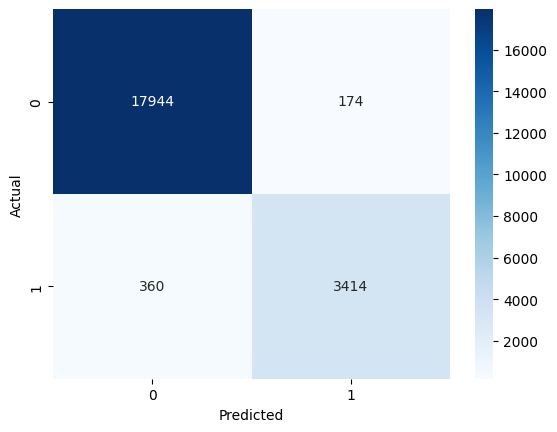

In [14]:
#confusion matrix

from sklearn.metrics import confusion_matrix, classification_report

y_pred = (model.predict(X_test) > 0.5).astype("int32")

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
#precision, recall and f1
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     18118
           1       0.95      0.90      0.93      3774

    accuracy                           0.98     21892
   macro avg       0.97      0.95      0.96     21892
weighted avg       0.98      0.98      0.98     21892



7. Model Size

In [16]:
model.count_params()

46785

8. Graph

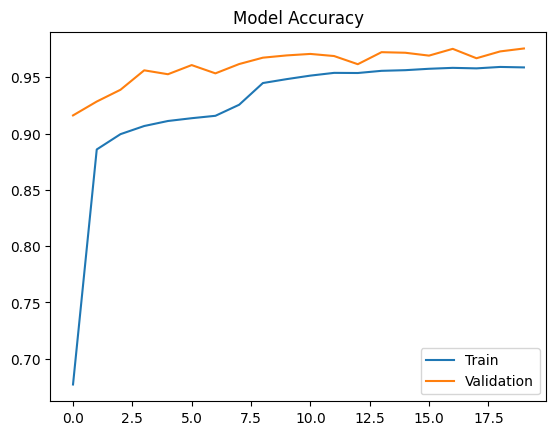

In [17]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()